#  Disease Prediction — Combined Model (BiLSTM + DistilBERT)


## 1. Install & Imports

In [1]:
!pip install transformers -q

import os, ast, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, Dropout,
    SpatialDropout1D, BatchNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# PyTorch + Transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel

# ── Seeds ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow :", tf.__version__)
print("PyTorch    :", torch.__version__)
print("GPU available:", torch.cuda.is_available())


2026-05-12 20:22:46.613676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778617366.997723      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778617367.118789      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778617368.081780      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778617368.081820      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778617368.081822      57 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
PyTorch    : 2.10.0+cu128
GPU available: True


## 2. Configuration

In [2]:
# ──────────────────────────────────────────────
#  CHANGE THIS PATH TO MATCH YOUR KAGGLE DATASET
# ──────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/habibaamramr/cleaned-medical-data/cleaned_medical_data.csv'
# BiLSTM hyper-params
MAX_WORDS = 3000
MAX_LEN   = 40

# DistilBERT hyper-params
BERT_MAX_LEN = 256
BERT_BATCH   = 16
BERT_EPOCHS  = 12
BERT_PATIENCE = 3

NUM_CLASSES = 4


## 3. Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(200)


Shape: (602, 7)


,disease,pubmed_id,abstract,symptoms,age,gender,drugs
0,covid-19,42083698,dengue hemorrhagic fever dhf is a severe form ...,"['abdominal pain', 'fever', 'headache', 'nausea']",17,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
1,covid-19,42078607,chronic inflammatory demyelinating polyneuropa...,"['arthralgia', 'cough', 'fatigue', 'fever', 'f...",20,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
2,covid-19,42078597,coronavirus disease 2019 covid-19 vaccines hav...,"['autoimmune hepatitis aih', 'progression to l...",64,male,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
3,covid-19,42078216,"paxlovid, a codrug of nirmatrelvirritonavir, h...","['bradycardia', 'hypotension']",81,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
4,covid-19,42076904,alport syndrome as is a hereditary nephropathy...,"['fever', 'fatigue', 'cough', 'headache', 'wea...",48,unknown,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
...,...,...,...,...,...,...,...
195,pneumonia,42016334,this case report describes a newborn diagnosed...,"['deformities', 'extremities', 'including defo...",48,unknown,"['amoxicillin', 'azithromycin', 'ceftriaxone',..."
196,pneumonia,42014252,liver transplantation in critically ill patien...,"['bradycardia', 'hypotension']",50,male,"['amoxicillin', 'azithromycin', 'ceftriaxone',..."
197,pneumonia,42011469,spontaneous atraumatic splenic rupture ssr is ...,"['abdominal pain', 'diffuse abdominal pain', '...",26,male,"['amoxicillin', 'azithromycin', 'ceftriaxone',..."
198,pneumonia,42006512,"daptomycin-induced eosinophilic pneumonia dep,...","['fever', 'cough', 'dyspnea', 'respiratory dis...",69,male,"['amoxicillin', 'azithromycin', 'ceftriaxone',..."


## 4. Exploratory Data Analysis (EDA)

In [4]:
# ── 4.1 Basic Info ──
print("=== Dataset Info ===")
print(df.info())
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()



=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   disease    602 non-null    object
 1   pubmed_id  602 non-null    int64 
 2   abstract   602 non-null    object
 3   symptoms   602 non-null    object
 4   age        602 non-null    int64 
 5   gender     602 non-null    object
 6   drugs      602 non-null    object
dtypes: int64(2), object(5)
memory usage: 33.1+ KB
None

=== Missing Values ===
disease      0
pubmed_id    0
abstract     0
symptoms     0
age          0
gender       0
drugs        0
dtype: int64



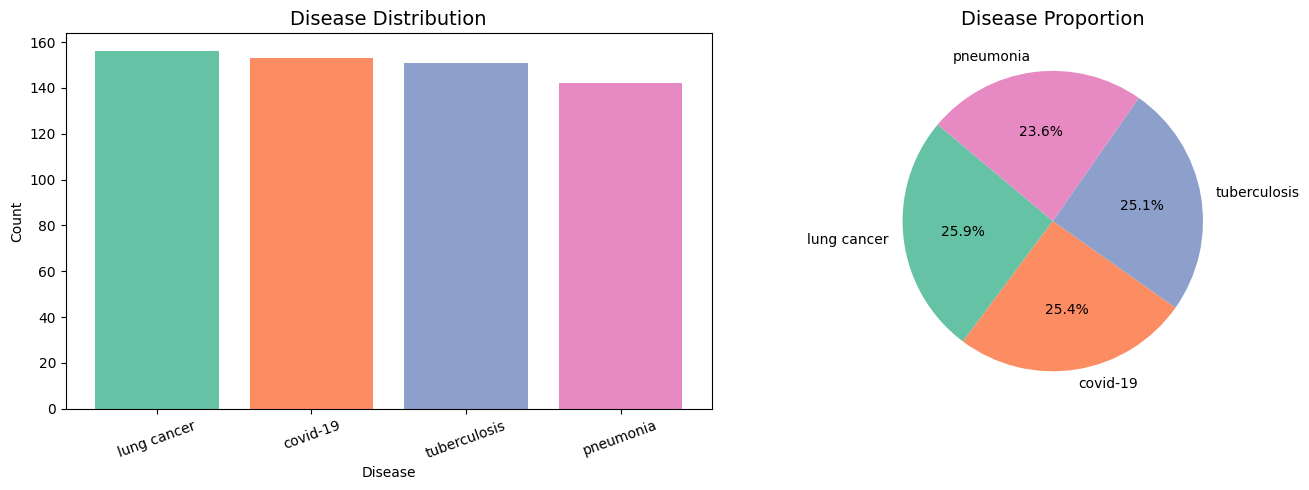

disease
lung cancer     156
covid-19        153
tuberculosis    151
pneumonia       142
Name: count, dtype: int64


In [5]:
# ── 4.2 Disease Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disease_counts = df['disease'].value_counts()
axes[0].bar(disease_counts.index, disease_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Disease Distribution', fontsize=14)
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(disease_counts.values, labels=disease_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'),
            startangle=140)
axes[1].set_title('Disease Proportion', fontsize=14)
plt.tight_layout()
plt.show()
print(disease_counts)


/tmp/ipykernel_57/71597962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'], palette='pastel', ax=axes[0])


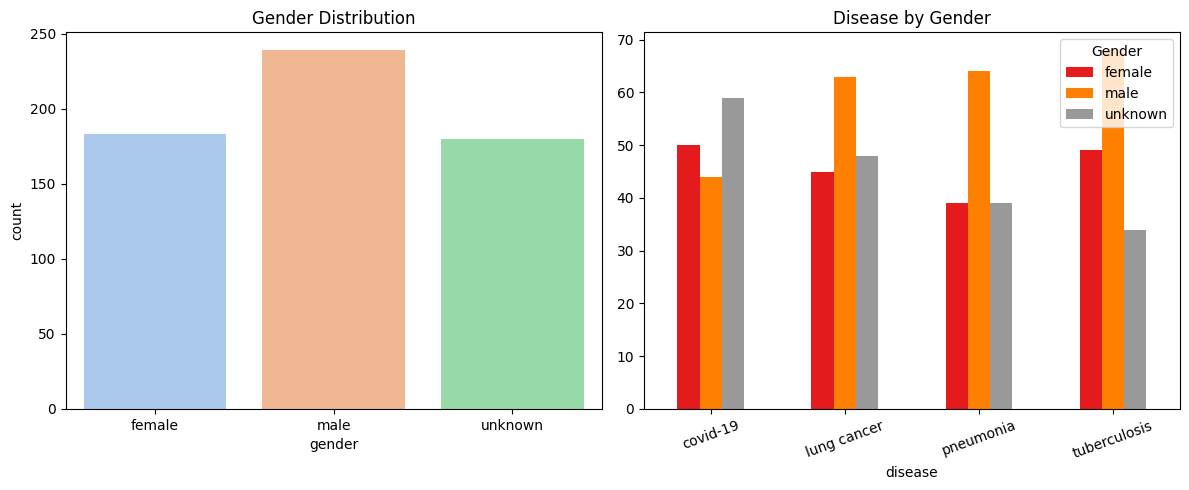

In [6]:
# ── 4.3 Gender Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['gender'].value_counts()
sns.countplot(x=df['gender'], palette='pastel', ax=axes[0])
axes[0].set_title('Gender Distribution')

# Gender × Disease
gender_disease = df.groupby(['disease', 'gender']).size().unstack(fill_value=0)
gender_disease.plot(kind='bar', ax=axes[1], colormap='Set1')
axes[1].set_title('Disease by Gender')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()


/tmp/ipykernel_57/3113041525.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease', y='age', data=df, palette='Set3', ax=axes[1])


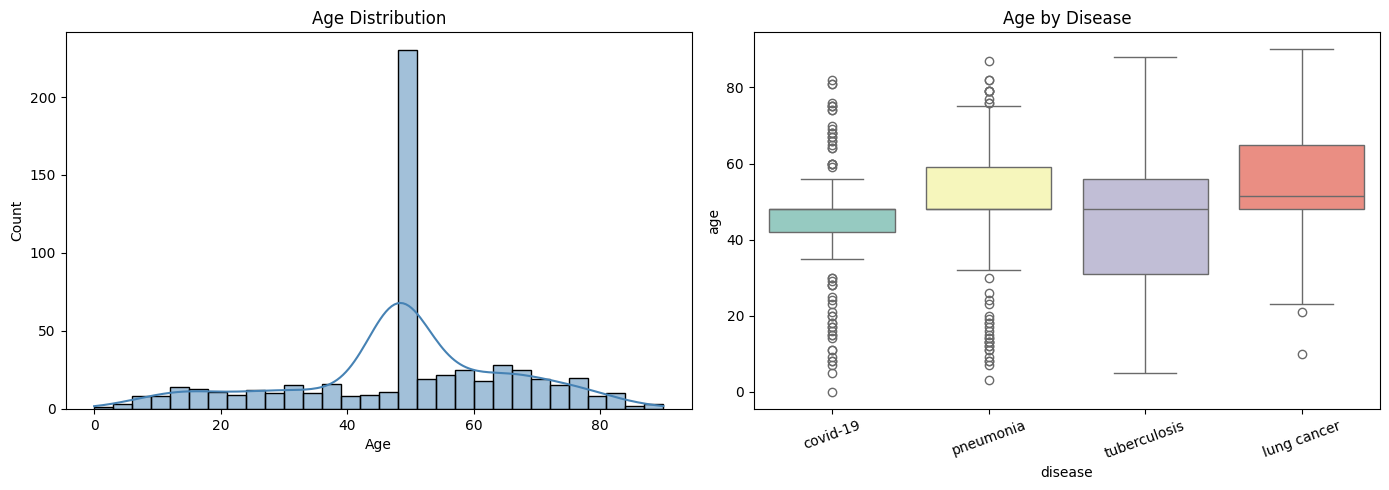

count    602.000000
mean      48.624585
std       17.370062
min        0.000000
25%       46.000000
50%       48.000000
75%       59.000000
max       90.000000
Name: age, dtype: float64


In [7]:
# ── 4.4 Age Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

sns.boxplot(x='disease', y='age', data=df, palette='Set3', ax=axes[1])
axes[1].set_title('Age by Disease')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print(df['age'].describe())


/tmp/ipykernel_57/2580247455.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease', y='text_length', data=df, palette='pastel', ax=axes[1])


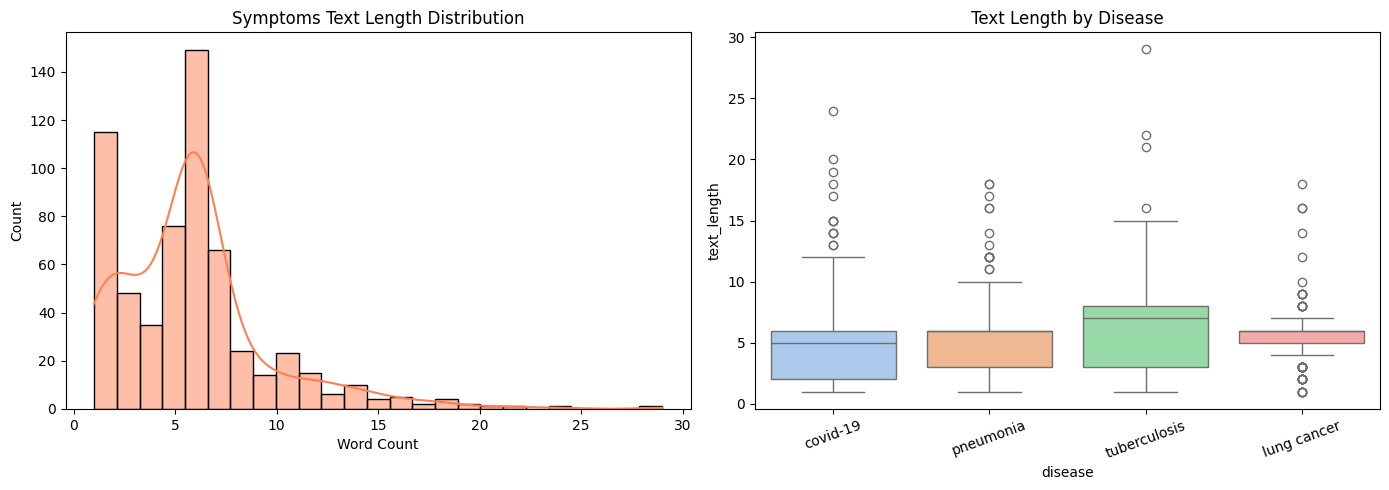

count    602.000000
mean       5.857143
std        3.767740
min        1.000000
25%        3.000000
50%        6.000000
75%        7.000000
max       29.000000
Name: text_length, dtype: float64


In [8]:
df['symptoms'] = df['symptoms'].astype(str).str.lower().str.strip()
df['text_length'] = df['symptoms'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['text_length'], bins=25, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Symptoms Text Length Distribution')
axes[0].set_xlabel('Word Count')

sns.boxplot(x='disease', y='text_length', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Text Length by Disease')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(df['text_length'].describe())

/tmp/ipykernel_57/1057476325.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


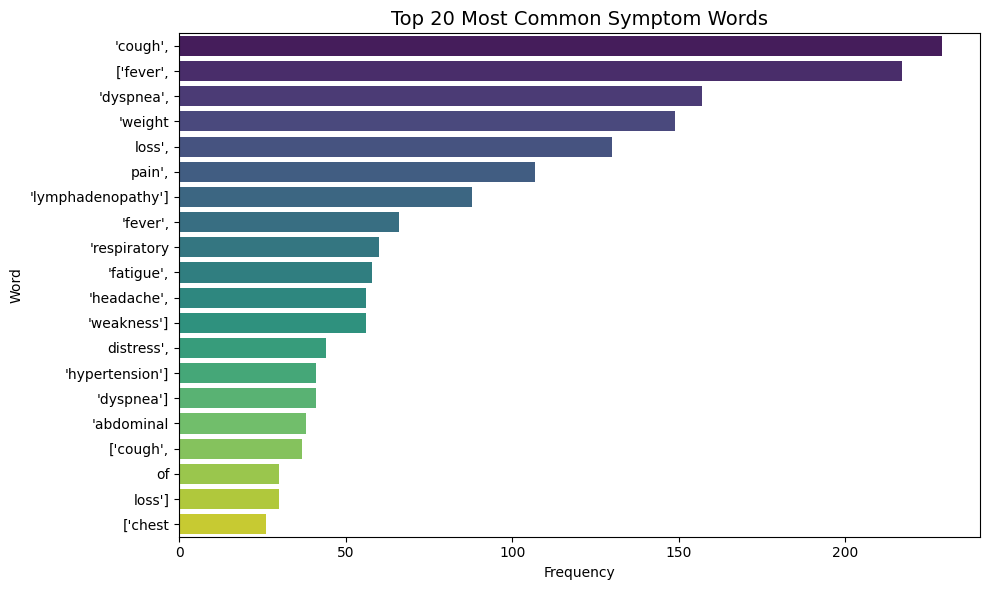

In [9]:
# ── 4.6 Most Common Words ──
all_words = ' '.join(df['symptoms']).split()
common_words = Counter(all_words).most_common(20)
words  = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Common Symptom Words', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


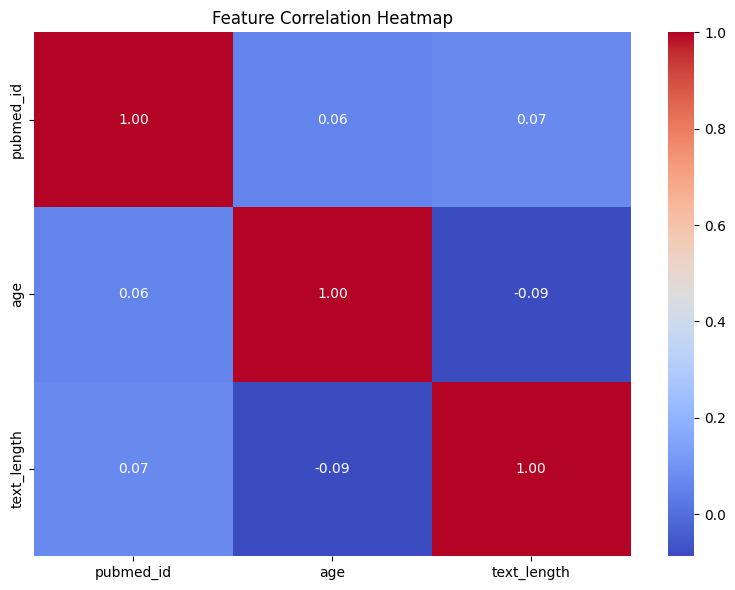

In [10]:
# ── 4.7 Correlation Heatmap (numeric features) ──
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()


## 5. Preprocessing (Shared)

In [11]:
# ── Label Encoding ──
disease_encoder = LabelEncoder()
df['disease_label'] = disease_encoder.fit_transform(df['disease'])
y = np.array(df['disease_label'], dtype=np.int32)

gender_encoder = LabelEncoder()
df['gender_encoded'] = gender_encoder.fit_transform(df['gender'])

print("Classes:", disease_encoder.classes_)
print("y shape:", y.shape)


Classes: ['covid-19' 'lung cancer' 'pneumonia' 'tuberculosis']
y shape: (602,)


In [12]:
# ── Meta Features (age + gender) ──
X_meta = np.array(df[['age', 'gender_encoded']], dtype=np.float32)
print("X_meta shape:", X_meta.shape)


X_meta shape: (602, 2)


In [13]:
# ── BiLSTM: Tokenize Text ──
tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df['symptoms'])
sequences = tokenizer_lstm.texts_to_sequences(df['symptoms'])
X_text = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
print("X_text shape:", X_text.shape)


X_text shape: (602, 40)


In [14]:
# ── Train / Test Split ──
(X_text_train, X_text_test,
 X_meta_train, X_meta_test,
 y_train,      y_test) = train_test_split(
    X_text, X_meta, y,
    test_size=0.2, random_state=SEED, stratify=y
)
print("Train size:", len(y_train), "| Test size:", len(y_test))


Train size: 481 | Test size: 121


## 6. Model 1 — BiLSTM + Meta Features
*(toka_model — unchanged)*

In [15]:
# ── Build BiLSTM Model ──
text_input = Input(shape=(MAX_LEN,), name='text_input')
embedding  = Embedding(input_dim=MAX_WORDS, output_dim=128)(text_input)
embedding  = SpatialDropout1D(0.3)(embedding)
lstm       = Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3))(embedding)

meta_input = Input(shape=(2,), name='meta_input')
meta_dense = Dense(32, activation='relu')(meta_input)
meta_dense = BatchNormalization()(meta_dense)

merged = Concatenate()([lstm, meta_dense])
dense  = Dense(128, activation='relu')(merged)
dense  = Dropout(0.4)(dense)
dense  = BatchNormalization()(dense)
dense  = Dense(64, activation='relu')(dense)
dense  = Dropout(0.3)(dense)
output = Dense(NUM_CLASSES, activation='softmax')(dense)

bilstm_model = Model(inputs=[text_input, meta_input], outputs=output, name='BiLSTM_Model')
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
bilstm_model.summary()


I0000 00:00:1778617424.464313      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778617424.470764      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 128)   │    384,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 40, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         96 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 288)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     36,992 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 693,412 (2.65 MB)

 Trainable params: 693,092 (2.64 MB)

 Non-trainable params: 320 (1.25 KB)

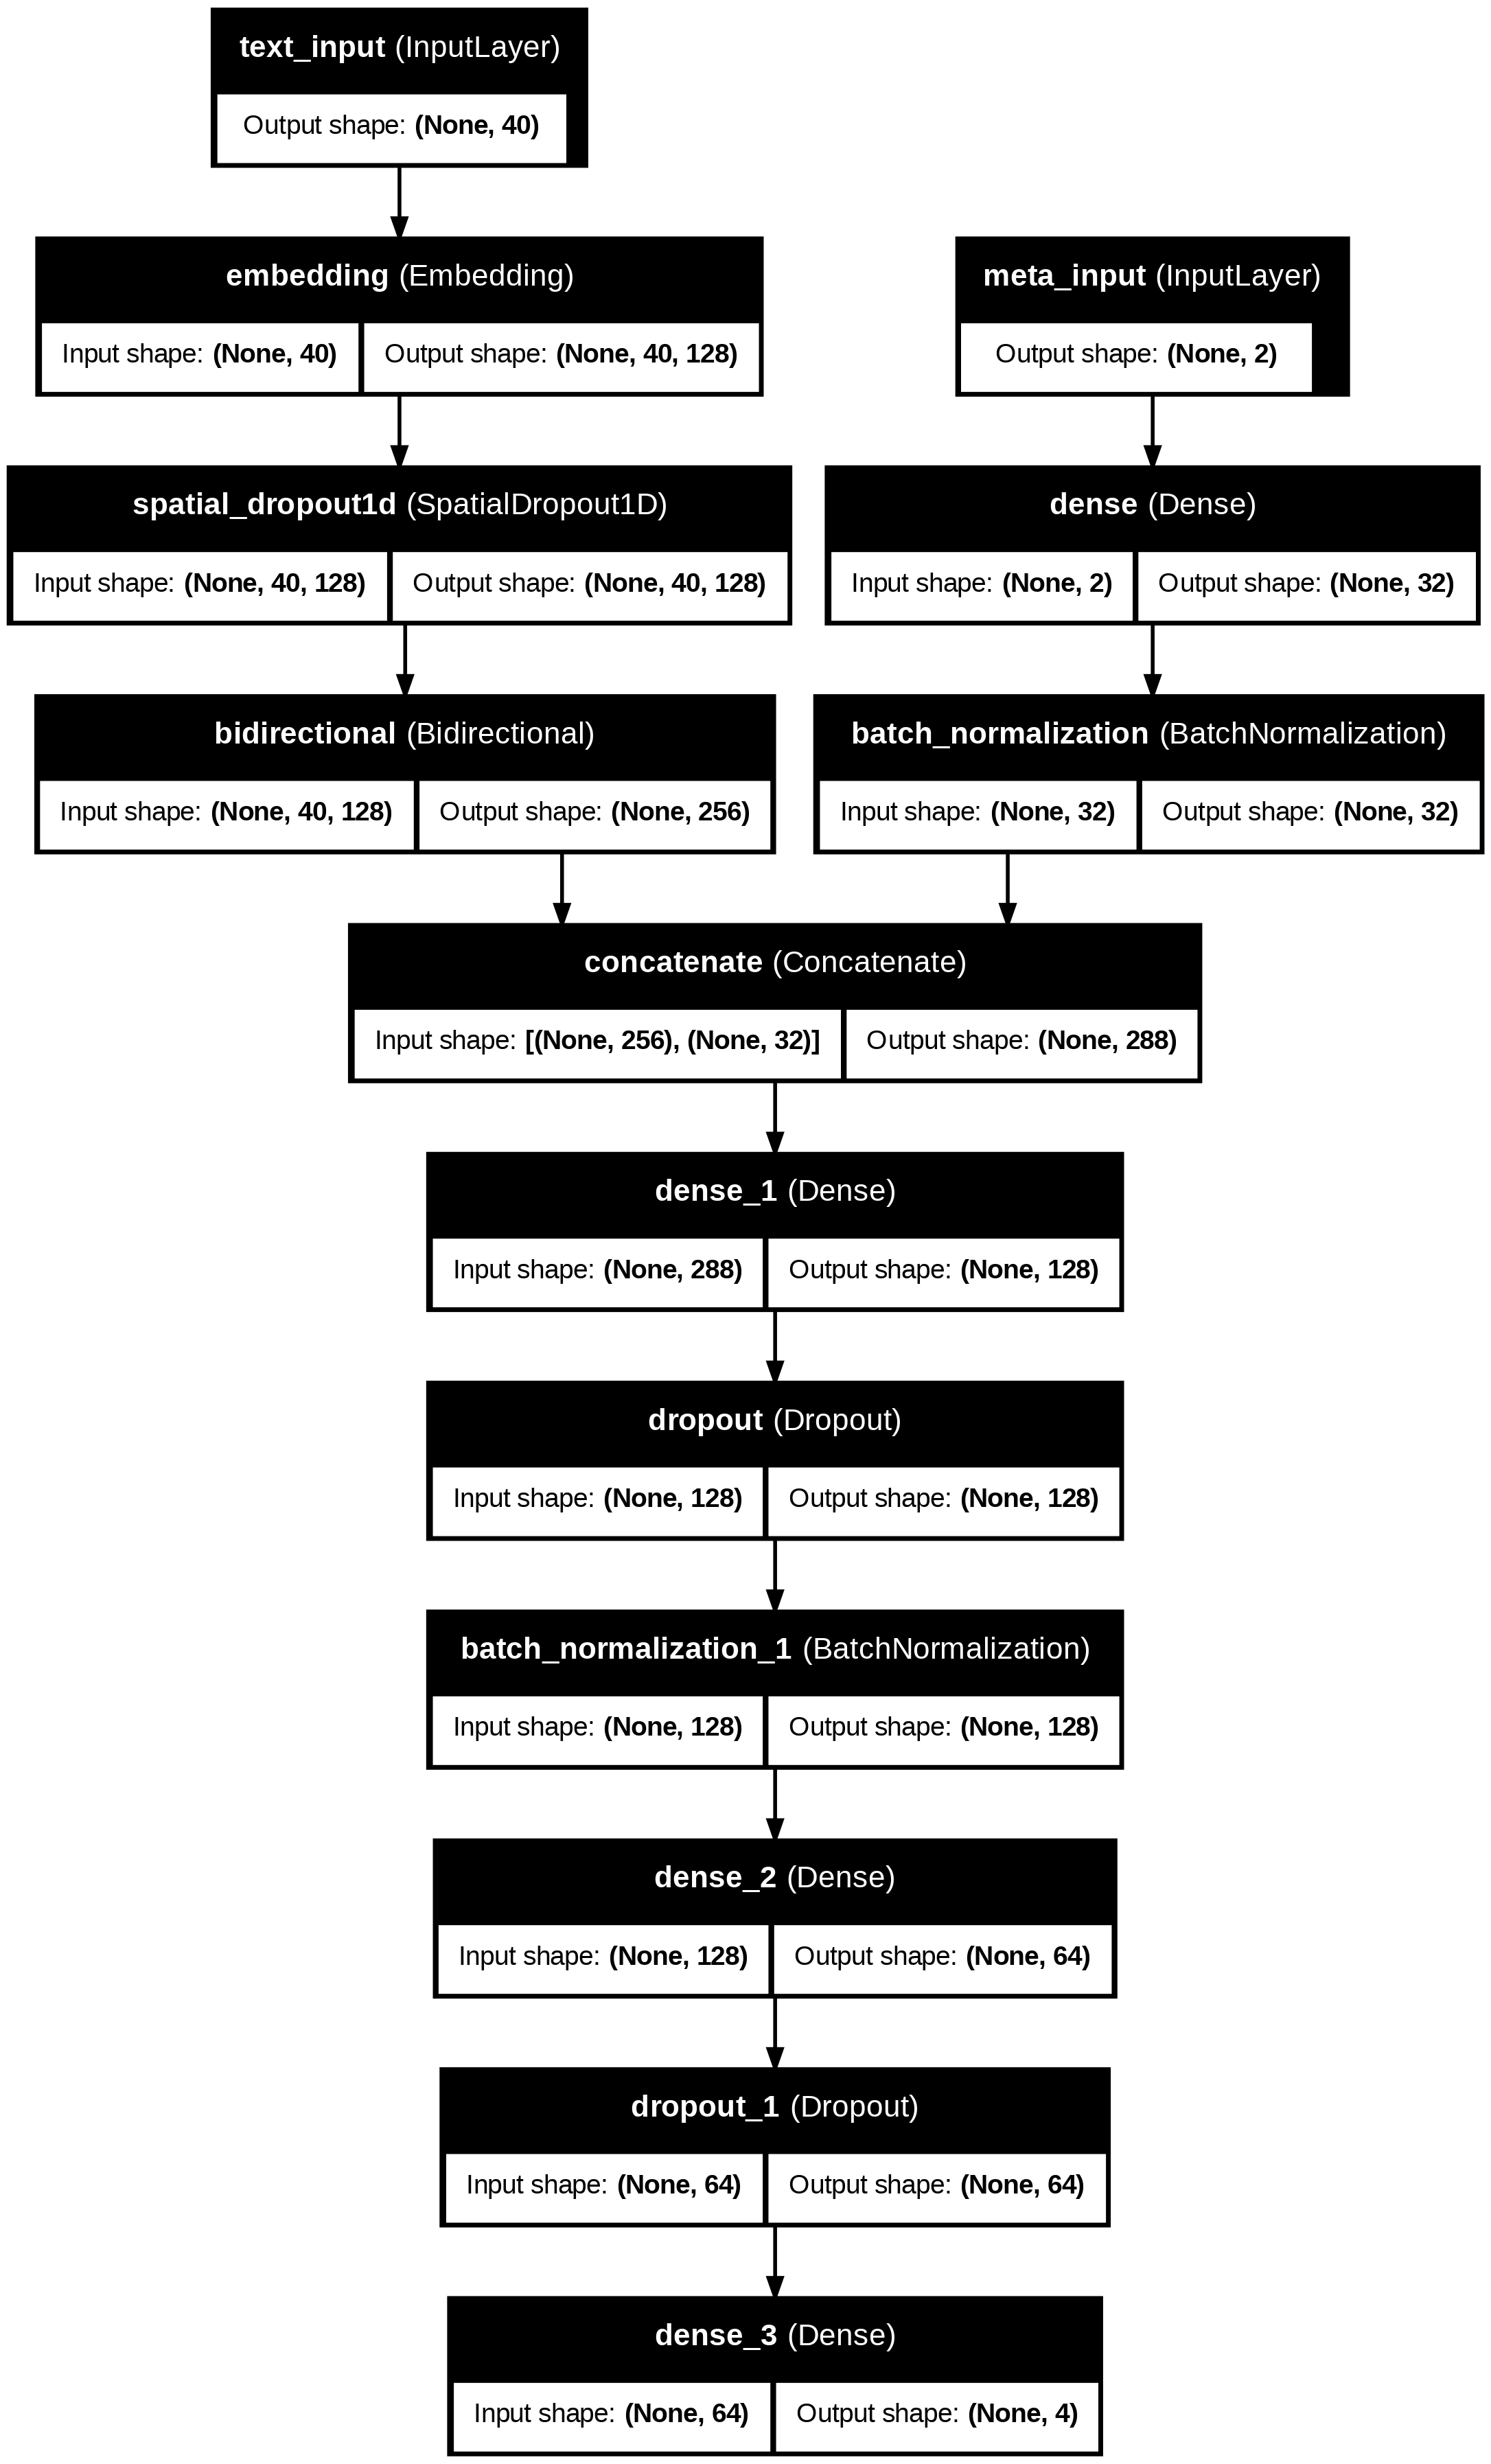

In [16]:
plot_model(bilstm_model, show_shapes=True, show_layer_names=True)


In [17]:
# ── Train BiLSTM ──
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

bilstm_history = bilstm_model.fit(
    [X_text_train, X_meta_train], y_train,
    validation_data=([X_text_test, X_meta_test], y_test),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Best Val Accuracy:", round(max(bilstm_history.history['val_accuracy']) * 100, 2), "%")


Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.2315 - loss: 1.7787 - val_accuracy: 0.2479 - val_loss: 1.4044 - learning_rate: 5.0000e-04
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.3292 - loss: 1.5268 - val_accuracy: 0.2645 - val_loss: 1.3990 - learning_rate: 5.0000e-04
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.3084 - loss: 1.5175 - val_accuracy: 0.2727 - val_loss: 1.3890 - learning_rate: 5.0000e-04
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.3144 - loss: 1.4569 - val_accuracy: 0.3058 - val_loss: 1.3850 - learning_rate: 5.0000e-04
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.3446 - loss: 1.4923 - val_accuracy: 0.3636 - val_loss: 1.3563 - learning_rate: 5.0000e-04
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.3933 - loss: 1.3194 - val_accuracy: 0.4628 - val_loss: 1.3049 - learning_rate: 5.0000e-04
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy:

In [18]:
# ── Evaluate BiLSTM ──
bilstm_preds = np.argmax(bilstm_model.predict([X_text_test, X_meta_test]), axis=1)
bilstm_acc   = accuracy_score(y_test, bilstm_preds)
print("BiLSTM Accuracy:", round(bilstm_acc * 100, 2), "%")
print()
bilstm_report = classification_report(
    y_test, bilstm_preds,
    target_names=disease_encoder.classes_,
    output_dict=True
)
print(classification_report(y_test, bilstm_preds, target_names=disease_encoder.classes_))

# ── Detailed Metrics Table ──
bilstm_metrics = pd.DataFrame(bilstm_report).T.rename(columns={"f1-score": "f1_score"})
bilstm_metrics.index.name = "Class"
print("\n=== BiLSTM — Per-Class Metrics (Precision / Recall / F1 / Support) ===")
print(bilstm_metrics[["precision", "recall", "f1_score", "support"]].round(4).to_string())


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step
BiLSTM Accuracy: 55.37 %

              precision    recall  f1-score   support

    covid-19       0.55      0.68      0.61        31
 lung cancer       0.76      0.52      0.62        31
   pneumonia       0.45      0.31      0.37        29
tuberculosis       0.50      0.70      0.58        30

    accuracy                           0.55       121
   macro avg       0.57      0.55      0.54       121
weighted avg       0.57      0.55      0.55       121


=== BiLSTM — Per-Class Metrics (Precision / Recall / F1 / Support) ===
              precision  recall  f1_score   support
Class                                              
covid-19         0.5526  0.6774    0.6087   31.0000
lung cancer      0.7619  0.5161    0.6154   31.0000
pneumonia        0.4500  0.3103    0.3673   29.0000
tuberculosis     0.5000  0.7000    0.5833   30.0000
accuracy         0.5537  0.5537    0.5537    0.5537
macro avg        0.5661  0.5510    0.5437  121.0000
weighted avg

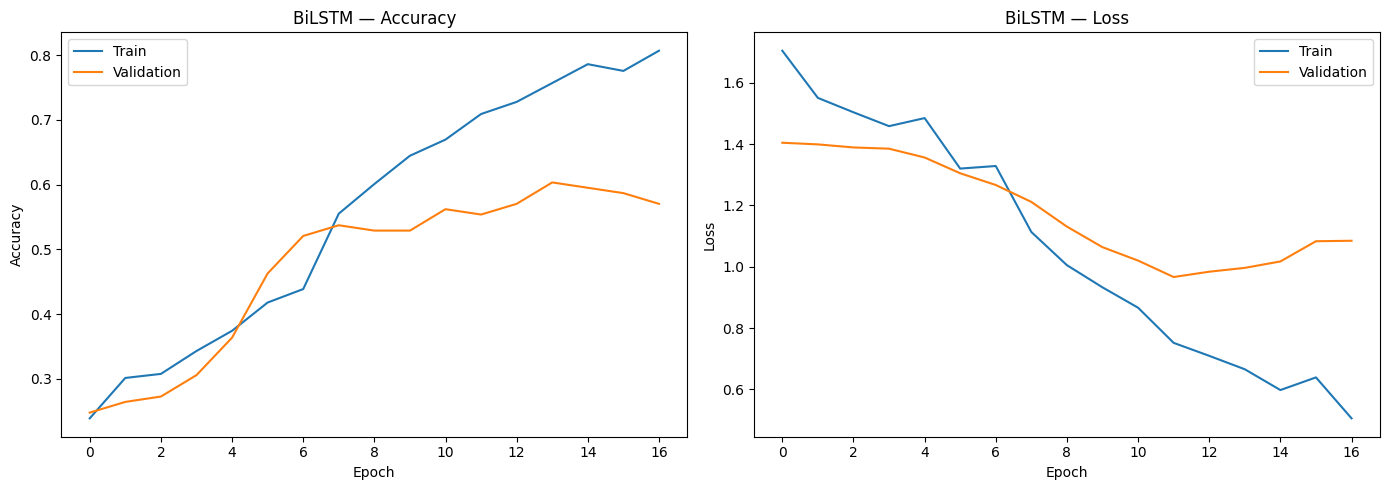

In [19]:
# ── BiLSTM Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bilstm_history.history['accuracy'],     label='Train')
axes[0].plot(bilstm_history.history['val_accuracy'], label='Validation')
axes[0].set_title('BiLSTM — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(bilstm_history.history['loss'],     label='Train')
axes[1].plot(bilstm_history.history['val_loss'], label='Validation')
axes[1].set_title('BiLSTM — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


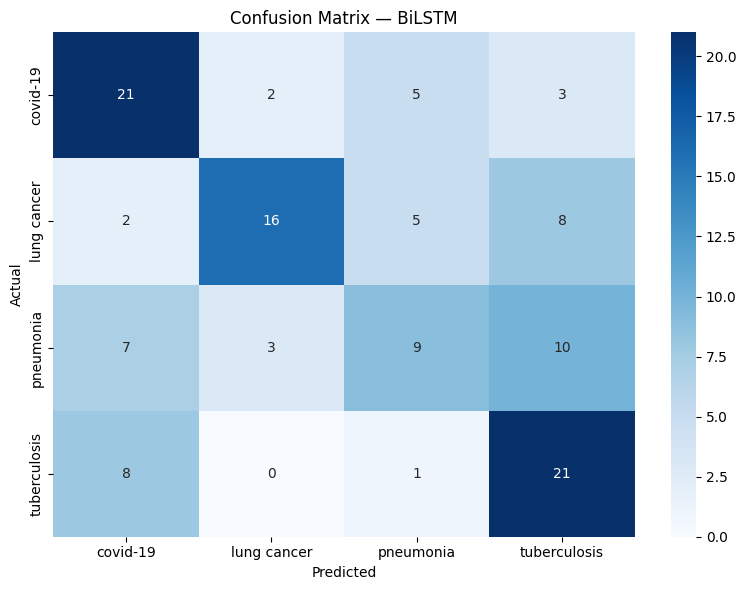

In [20]:
# ── BiLSTM Confusion Matrix ──
cm = confusion_matrix(y_test, bilstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_encoder.classes_,
            yticklabels=disease_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — BiLSTM')
plt.tight_layout()
plt.show()


In [21]:
# ── Save BiLSTM Probabilities ──
bilstm_probs = bilstm_model.predict([X_text_test, X_meta_test])
np.save('bilstm_probs.npy', bilstm_probs)
print("BiLSTM probs saved:", bilstm_probs.shape)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
BiLSTM probs saved: (121, 4)


## 7. Model 2 — DistilBERT Fine-Tuning + Meta Features
*(moemen_model — with proper fine-tuning fix)*

In [22]:
# ── 7.1 Prepare DistilBERT inputs ──

import ast

# Build text_input combining abstract + symptoms
if 'abstract' in df.columns:

    # convert symptoms string-list to actual list
    df['symptoms'] = df['symptoms'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
    )

    # combine abstract + symptoms
    df['text_input'] = (
        df['abstract'].astype(str) + ' ' +
        df['symptoms'].apply(
            lambda x: ' '.join(x) if isinstance(x, list) else str(x)
        )
    )

else:
    # fallback if no abstract column
    df['text_input'] = df['symptoms'].astype(str)

# Inputs
X_bert_text   = df['text_input'].values
X_bert_struct = np.array(df[['age', 'gender_encoded']], dtype=float)

# Labels
y_bert = df['disease_label'].values

# Split
(X_bt_train, X_bt_test,
 X_bs_train, X_bs_test,
 yb_train, yb_test) = train_test_split(
    X_bert_text,
    X_bert_struct,
    y_bert,
    test_size=0.2,
    stratify=y_bert,
    random_state=SEED
)

print("BERT Train:", len(yb_train), "| Test:", len(yb_test))

BERT Train: 481 | Test: 121


In [23]:
# ── 7.2 Tokenize for DistilBERT ──
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def bert_tokenize(texts, max_len=BERT_MAX_LEN):
    return bert_tokenizer(
        list(texts),
        max_length=max_len,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

train_encodings = bert_tokenize(X_bt_train)
test_encodings  = bert_tokenize(X_bt_test)
print("Train tokens:", train_encodings['input_ids'].shape)
print("Test tokens :", test_encodings['input_ids'].shape)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train tokens: torch.Size([481, 256])
Test tokens : torch.Size([121, 256])


In [24]:
# ── 7.3 Dataset & DataLoader ──
class MedicalDataset(Dataset):
    def __init__(self, encodings, struct_features, labels):
        self.encodings = encodings
        self.struct    = torch.tensor(struct_features, dtype=torch.float32)
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'struct':         self.struct[idx],
            'label':          self.labels[idx]
        }

train_ds = MedicalDataset(train_encodings, X_bs_train, yb_train)
test_ds  = MedicalDataset(test_encodings,  X_bs_test,  yb_test)

train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH, shuffle=False)

print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))


Train batches: 31 | Test batches: 8


In [25]:
# ── 7.4 DistilBERT Classifier (Fine-Tuning)

class DistilBertClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Freeze all layers first
        for param in self.bert.parameters():
            param.requires_grad = False

        #  Unfreeze last transformer layer for fine-tuning
        for param in self.bert.transformer.layer[-1].parameters():
            param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(768 + 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, struct):
        output    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = output.last_hidden_state[:, 0, :]
        combined  = torch.cat([cls_token, struct], dim=1)
        return self.classifier(combined)

bert_model = DistilBertClassifier()

# Count trainable params
trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bert_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 7,286,276 / 66,561,284 (10.9%)


In [26]:
# ── 7.5 Training Setup ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bert_model = bert_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([
    {'params': bert_model.bert.transformer.layer[-1].parameters(), 'lr': 2e-5},
    {'params': bert_model.classifier.parameters(),                  'lr': 2e-4}
])

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        struct         = batch['struct'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, struct)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            struct         = batch['struct'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, struct)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


Device: cuda


In [27]:
# ── 7.6 Train DistilBERT ──
best_loss = float('inf')
counter   = 0
bert_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(BERT_EPOCHS):
    t_loss, t_acc = train_epoch(bert_model, train_loader)
    v_loss, v_acc = eval_epoch(bert_model,  test_loader)

    bert_history['train_loss'].append(t_loss)
    bert_history['train_acc'].append(t_acc)
    bert_history['val_loss'].append(v_loss)
    bert_history['val_acc'].append(v_acc)

    print(f"Epoch {epoch+1}/{BERT_EPOCHS} | "
          f"Train Loss: {t_loss:.3f} | Train Acc: {t_acc:.3f} | "
          f"Val Loss: {v_loss:.3f} | Val Acc: {v_acc:.3f}")

    if v_loss < best_loss:
        best_loss = v_loss
        counter   = 0
        torch.save(bert_model.state_dict(), 'best_bert_model.pt')
        print("  Best model saved!")
    else:
        counter += 1
        print(f"  No improvement {counter}/{BERT_PATIENCE}")
        if counter >= BERT_PATIENCE:
            print("  Early stopping!")
            break

bert_model.load_state_dict(torch.load('best_bert_model.pt'))
print("Best model loaded!")


Epoch 1/12 | Train Loss: 1.415 | Train Acc: 0.281 | Val Loss: 1.342 | Val Acc: 0.322
  Best model saved!
Epoch 2/12 | Train Loss: 1.359 | Train Acc: 0.347 | Val Loss: 1.231 | Val Acc: 0.512
  Best model saved!
Epoch 3/12 | Train Loss: 1.198 | Train Acc: 0.495 | Val Loss: 0.941 | Val Acc: 0.645
  Best model saved!
Epoch 4/12 | Train Loss: 0.876 | Train Acc: 0.701 | Val Loss: 0.707 | Val Acc: 0.760
  Best model saved!
Epoch 5/12 | Train Loss: 0.669 | Train Acc: 0.780 | Val Loss: 0.658 | Val Acc: 0.785
  Best model saved!
Epoch 6/12 | Train Loss: 0.664 | Train Acc: 0.788 | Val Loss: 0.638 | Val Acc: 0.785
  Best model saved!
Epoch 7/12 | Train Loss: 0.577 | Train Acc: 0.807 | Val Loss: 0.606 | Val Acc: 0.793
  Best model saved!
Epoch 8/12 | Train Loss: 0.425 | Train Acc: 0.875 | Val Loss: 0.642 | Val Acc: 0.760
  No improvement 1/3
Epoch 9/12 | Train Loss: 0.406 | Train Acc: 0.859 | Val Loss: 0.607 | Val Acc: 0.810
  No improvement 2/3
Epoch 10/12 | Train Loss: 0.378 | Train Acc: 0.892 | 

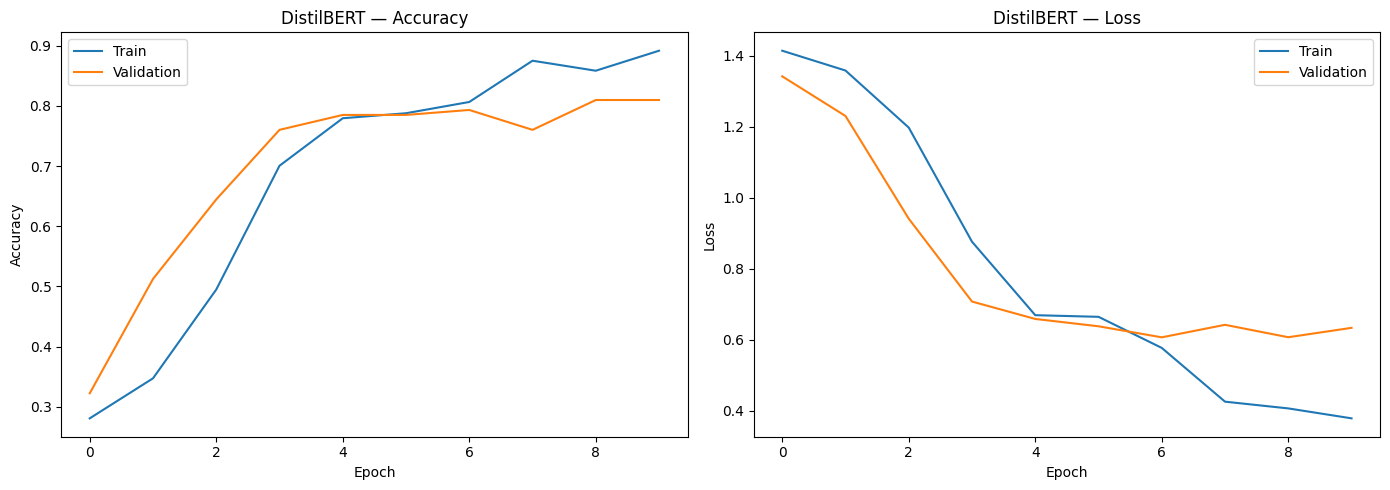

In [28]:
# ── 7.7 DistilBERT Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bert_history['train_acc'], label='Train')
axes[0].plot(bert_history['val_acc'],   label='Validation')
axes[0].set_title('DistilBERT — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(bert_history['train_loss'], label='Train')
axes[1].plot(bert_history['val_loss'],   label='Validation')
axes[1].set_title('DistilBERT — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [29]:
# ── 7.8 Evaluate DistilBERT ──
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        outputs = bert_model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['struct'].to(device)
        )
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

bert_acc = accuracy_score(all_labels, all_preds)
print("DistilBERT Accuracy:", round(bert_acc * 100, 2), "%")
print()
bert_report = classification_report(
    all_labels, all_preds,
    target_names=disease_encoder.classes_,
    output_dict=True
)
print(classification_report(all_labels, all_preds, target_names=disease_encoder.classes_))

# ── Detailed Metrics Table ──
bert_metrics = pd.DataFrame(bert_report).T.rename(columns={"f1-score": "f1_score"})
bert_metrics.index.name = "Class"
print("\n=== DistilBERT — Per-Class Metrics (Precision / Recall / F1 / Support) ===")
print(bert_metrics[["precision", "recall", "f1_score", "support"]].round(4).to_string())


DistilBERT Accuracy: 79.34 %

              precision    recall  f1-score   support

    covid-19       0.83      0.77      0.80        31
 lung cancer       0.79      0.84      0.81        31
   pneumonia       0.70      0.66      0.68        29
tuberculosis       0.84      0.90      0.87        30

    accuracy                           0.79       121
   macro avg       0.79      0.79      0.79       121
weighted avg       0.79      0.79      0.79       121


=== DistilBERT — Per-Class Metrics (Precision / Recall / F1 / Support) ===
              precision  recall  f1_score   support
Class                                              
covid-19         0.8276  0.7742    0.8000   31.0000
lung cancer      0.7879  0.8387    0.8125   31.0000
pneumonia        0.7037  0.6552    0.6786   29.0000
tuberculosis     0.8438  0.9000    0.8710   30.0000
accuracy         0.7934  0.7934    0.7934    0.7934
macro avg        0.7907  0.7920    0.7905  121.0000
weighted avg     0.7917  0.7934    0.7917  

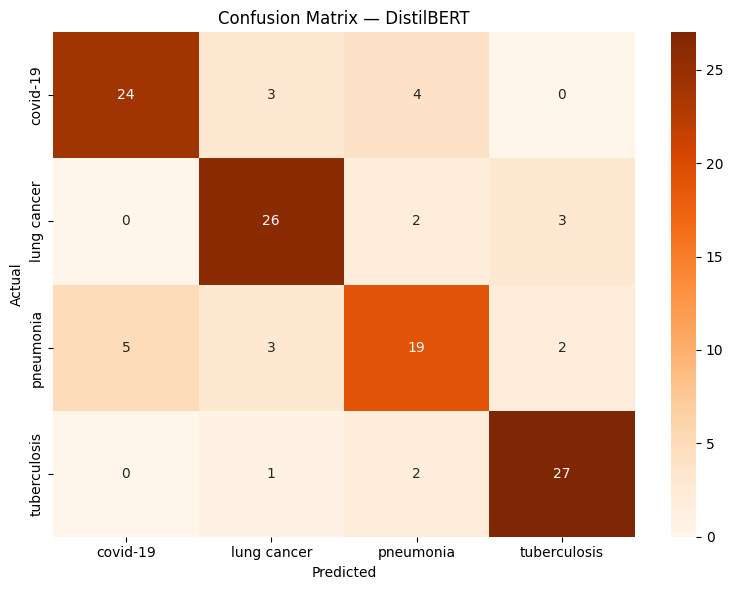

In [30]:
# ── 7.9 DistilBERT Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=disease_encoder.classes_,
            yticklabels=disease_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — DistilBERT')
plt.tight_layout()
plt.show()


In [31]:
# ── 7.10 Save DistilBERT Probabilities ──
bert_model.eval()
distilbert_probs = []

with torch.no_grad():
    for batch in test_loader:
        outputs = bert_model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['struct'].to(device)
        )
        probs = F.softmax(outputs, dim=1)
        distilbert_probs.extend(probs.cpu().numpy())

distilbert_probs = np.array(distilbert_probs)
np.save('distilbert_probs.npy', distilbert_probs)
print("DistilBERT probs saved:", distilbert_probs.shape)


DistilBERT probs saved: (121, 4)


## 9. Models Comparison

            Model  Accuracy
    BiLSTM + Meta  0.553719
DistilBERT + Meta  0.793388


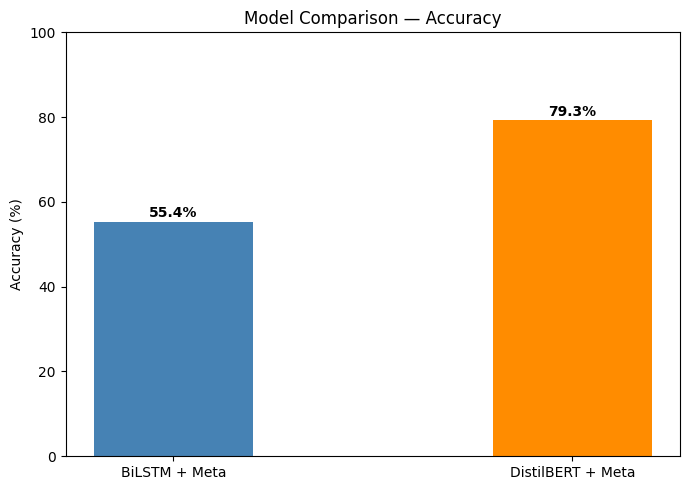

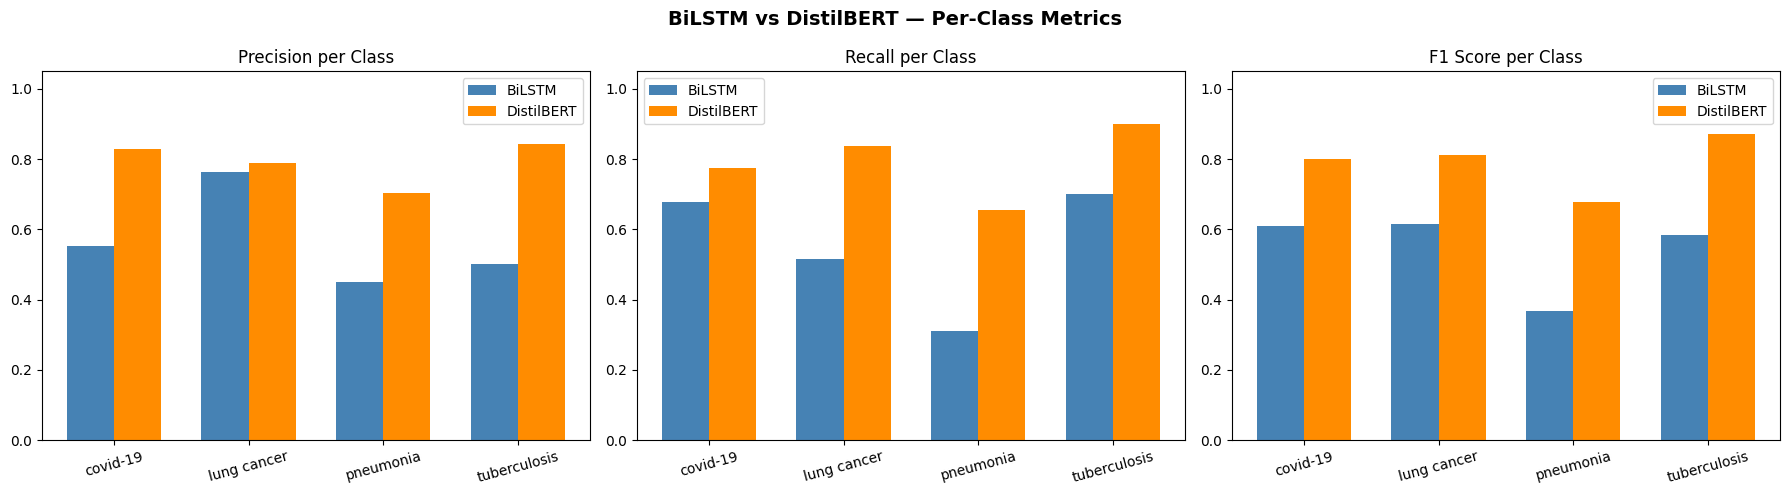


=== Summary Averages ===
                           BiLSTM   DistilBERT

  Macro Avg
    precision                0.5661       0.7907
    recall                   0.5510       0.7920
    f1_score                 0.5437       0.7905

  Weighted Avg
    precision                0.5686       0.7917
    recall                   0.5537       0.7934
    f1_score                 0.5463       0.7917


In [32]:
# ── Accuracy Comparison ──
results = pd.DataFrame({
    'Model':    ['BiLSTM + Meta', 'DistilBERT + Meta'],
    'Accuracy': [bilstm_acc,       bert_acc]
})

print(results.to_string(index=False))

plt.figure(figsize=(7, 5))
bars = plt.bar(results['Model'], results['Accuracy'] * 100,
               color=['steelblue', 'darkorange'], width=0.4)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison — Accuracy')
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-Class Metrics Comparison (Precision / Recall / F1) ──
classes       = list(disease_encoder.classes_)
metrics_names = ['precision', 'recall', 'f1_score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x     = np.arange(len(classes))
width = 0.35

for ax, metric in zip(axes, metrics_names):
    bilstm_vals = [bilstm_metrics.loc[c, metric] for c in classes]
    bert_vals   = [bert_metrics.loc[c, metric]   for c in classes]
    ax.bar(x - width/2, bilstm_vals, width, label='BiLSTM',     color='steelblue')
    ax.bar(x + width/2, bert_vals,   width, label='DistilBERT', color='darkorange')
    ax.set_title(f'{metric.replace("_", " ").title()} per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.suptitle('BiLSTM vs DistilBERT — Per-Class Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Macro / Weighted Averages Summary ──
print("\n=== Summary Averages ===")
header = f"{'':22} {'BiLSTM':>10} {'DistilBERT':>12}"
print(header)
for row in ['macro avg', 'weighted avg']:
    print(f"\n  {row.title()}")
    for m in ['precision', 'recall', 'f1_score']:
        bv = bilstm_metrics.loc[row, m]
        dv = bert_metrics.loc[row, m]
        print(f"    {m:20} {bv:>10.4f} {dv:>12.4f}")


## 10. Save Artifacts

In [33]:
# ── Save BiLSTM ──
bilstm_model.save('bilstm_model.keras')
print("BiLSTM model saved  → bilstm_model.keras")

# ── Save DistilBERT (already saved during training as best checkpoint) ──
print("DistilBERT model saved → best_bert_model.pt")

# ── Save Probabilities ──
bilstm_probs_save = bilstm_model.predict([X_text_test, X_meta_test])
np.save('bilstm_probs.npy', bilstm_probs_save)
print("BiLSTM probs saved  → bilstm_probs.npy")

bert_model.eval()
distilbert_probs_save = []
with torch.no_grad():
    for batch in test_loader:
        outputs = bert_model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['struct'].to(device)
        )
        probs = F.softmax(outputs, dim=1)
        distilbert_probs_save.extend(probs.cpu().numpy())
distilbert_probs_save = np.array(distilbert_probs_save)
np.save('distilbert_probs.npy', distilbert_probs_save)
print("DistilBERT probs saved → distilbert_probs.npy")

# ── Save Encoders & Tokenizer ──
with open('tokenizer_lstm.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
with open('disease_encoder.pkl', 'wb') as f:
    pickle.dump(disease_encoder, f)
with open('gender_encoder.pkl', 'wb') as f:
    pickle.dump(gender_encoder, f)

print("\nAll artifacts saved successfully!")
print("   bilstm_model.keras")
print("   best_bert_model.pt")
print("   bilstm_probs.npy")
print("   distilbert_probs.npy")
print("   tokenizer_lstm.pkl")
print("   disease_encoder.pkl")
print("   gender_encoder.pkl")


BiLSTM model saved  → bilstm_model.keras
DistilBERT model saved → best_bert_model.pt
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
BiLSTM probs saved  → bilstm_probs.npy
DistilBERT probs saved → distilbert_probs.npy

All artifacts saved successfully!
   bilstm_model.keras
   best_bert_model.pt
   bilstm_probs.npy
   distilbert_probs.npy
   tokenizer_lstm.pkl
   disease_encoder.pkl
   gender_encoder.pkl


## 11. Prediction Function

In [34]:
def predict_disease(symptoms: str, age: int, gender: str) -> None:
    """Predict disease using BiLSTM and DistilBERT separately."""
    symptoms = symptoms.lower().strip()
    g_enc    = gender_encoder.transform([gender])[0]

    # ── BiLSTM ──
    seq    = tokenizer_lstm.texts_to_sequences([symptoms])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    meta   = np.array([[age, g_enc]], dtype=np.float32)
    lstm_p = bilstm_model.predict([padded, meta], verbose=0)[0]
    lstm_pred = disease_encoder.inverse_transform([np.argmax(lstm_p)])[0]

    # ── DistilBERT ──
    enc = bert_tokenizer(symptoms, max_length=BERT_MAX_LEN,
                         padding='max_length', truncation=True,
                         return_tensors='pt')
    struct_t = torch.tensor([[age, g_enc]], dtype=torch.float32).to(device)
    bert_model.eval()
    with torch.no_grad():
        out    = bert_model(enc['input_ids'].to(device),
                            enc['attention_mask'].to(device),
                            struct_t)
        bert_p = F.softmax(out, dim=1).cpu().numpy()[0]
    bert_pred = disease_encoder.inverse_transform([np.argmax(bert_p)])[0]

    # ── Display Results ──
    display_symptoms = (symptoms[:60] + '...') if len(symptoms) > 60 else symptoms
    print("=" * 52)
    print(f"  Symptoms : {display_symptoms}")
    print(f"  Age: {age}  |  Gender: {gender}")
    print("-" * 52)

    for model_name, probs, pred in [
        ("BiLSTM",     lstm_p, lstm_pred),
        ("DistilBERT", bert_p, bert_pred)
    ]:
        print(f"\n  [{model_name}]  → {pred}  (confidence: {max(probs)*100:.1f}%)")
        for idx, p in enumerate(probs):
            name = disease_encoder.inverse_transform([idx])[0]
            bar  = "█" * int(p * 30)
            print(f"    {name:<22} {p*100:5.1f}%  {bar}")

    print("=" * 52)


In [35]:
#  COVID-19

predict_disease(
    symptoms="fever dry cough fatigue loss of smell sore throat headache",
    age=28,
    gender="female"
)

predict_disease(
    symptoms="high fever body aches dry cough chills loss of taste fatigue",
    age=45,
    gender="male"
)

predict_disease(
    symptoms="mild fever cough sore throat runny nose headache fatigue",
    age=22,
    gender="female"
)


# Pneumonia
predict_disease(
    symptoms="high fever productive cough chest pain shortness of breath chills fatigue",
    age=65,
    gender="male"
)

predict_disease(
    symptoms="severe chest pain coughing mucus difficulty breathing fever sweating weakness",
    age=70,
    gender="female"
)

predict_disease(
    symptoms="wet cough fever chest discomfort rapid breathing fatigue chills",
    age=50,
    gender="male"
)


# Tuberculosis

predict_disease(
    symptoms="long term cough night sweats fever weight loss chest pain coughing blood fatigue",
    age=40,
    gender="female"
)

predict_disease(
    symptoms="persistent cough fever night sweats weight loss weakness chest pain blood in cough",
    age=35,
    gender="male"
)

predict_disease(
    symptoms="chronic cough low grade fever night sweats fatigue loss of weight chest discomfort",
    age=29,
    gender="female"
)

  Symptoms : fever dry cough fatigue loss of smell sore throat headache
  Age: 28  |  Gender: female
----------------------------------------------------

  [BiLSTM]  → tuberculosis  (confidence: 34.5%)
    covid-19                24.7%  ███████
    lung cancer             24.0%  ███████
    pneumonia               16.8%  █████
    tuberculosis            34.5%  ██████████

  [DistilBERT]  → covid-19  (confidence: 40.9%)
    covid-19                40.9%  ████████████
    lung cancer              5.0%  █
    pneumonia               38.1%  ███████████
    tuberculosis            16.0%  ████
  Symptoms : high fever body aches dry cough chills loss of taste fatigue
  Age: 45  |  Gender: male
----------------------------------------------------

  [BiLSTM]  → tuberculosis  (confidence: 37.2%)
    covid-19                25.2%  ███████
    lung cancer             23.3%  ██████
    pneumonia               14.3%  ████
    tuberculosis            37.2%  ███████████

  [DistilBERT]  → covid-19 

In [41]:
# ══════════════════════════════════════════════════════════
# DOWNLOAD — DistilBERT Fusion Files
# الـ 5 ملفات المطلوبة للـ Late Fusion (DistilBERT فقط)
# ══════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F

# ── 1) distilbert_probs.npy ──────────────────────────────
# (بنعيد يعملها fresh من أحسن checkpoint)
bert_model.eval()
distilbert_probs_final = []
with torch.no_grad():
    for batch in test_loader:
        outputs = bert_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["struct"].to(device)
        )
        probs = F.softmax(outputs, dim=1)
        distilbert_probs_final.extend(probs.cpu().numpy())
distilbert_probs_final = np.array(distilbert_probs_final)
np.save("distilbert_probs.npy", distilbert_probs_final)
print(f"[1/5] distilbert_probs.npy  → shape: {distilbert_probs_final.shape}")

# ── 2) best_bert_model.pt ────────────────────────────────
# (اتحفظ أوتوماتيك أثناء التدريب، بس نتأكد)
assert os.path.exists("best_bert_model.pt"), "best_bert_model.pt مش موجود!"
print("[2/5] best_bert_model.pt    → OK")

# ── 3) disease_encoder.pkl ───────────────────────────────
with open("disease_encoder.pkl", "wb") as f:
    pickle.dump(disease_encoder, f)
print(f"[3/5] disease_encoder.pkl   → classes: {list(disease_encoder.classes_)}")

# ── 4) gender_encoder.pkl ────────────────────────────────
with open("gender_encoder.pkl", "wb") as f:
    pickle.dump(gender_encoder, f)
print(f"[4/5] gender_encoder.pkl    → classes: {list(gender_encoder.classes_)}")


# ── Download ─────────────────────────────────────────────
# ── Download ─────────────────────────────────────────────
print("\n" + "="*45)
print("Downloading all 5 files...")
print("="*45)

from google.colab import files

fusion_files = [
    "distilbert_probs.npy",
    "best_bert_model.pt",
    "disease_encoder.pkl",
    "gender_encoder.pkl",
]

for fname in fusion_files:
    files.download(fname)
    print(f"  ✓ {fname}")

print("\nDone! all files Downloaded.")

[1/5] distilbert_probs.npy  → shape: (121, 4)
[2/5] best_bert_model.pt    → OK
[3/5] disease_encoder.pkl   → classes: ['covid-19', 'lung cancer', 'pneumonia', 'tuberculosis']
[4/5] gender_encoder.pkl    → classes: ['female', 'male', 'unknown']



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ distilbert_probs.npy


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ disease_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ gender_encoder.pkl

Done! all files Downloaded.


In [42]:
import os
files = ['distilbert_probs.npy', 'best_bert_model.pt', 
         'disease_encoder.pkl', 'gender_encoder.pkl']
for f in files:
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"✓ {f}  →  {size/1024:.1f} KB")

✓ distilbert_probs.npy  →  2.0 KB
✓ best_bert_model.pt  →  260045.7 KB
✓ disease_encoder.pkl  →  0.3 KB
✓ gender_encoder.pkl  →  0.3 KB
